In [1]:
!pip install yfinance pandas arch

In [2]:
#Importing 5 years stock data for Target
import yfinance as yf
import pandas as pd

# Define the ticker symbol and the date range
ticker_symbol = "TGT"
start_date = "2020-01-01"
end_date = "2025-01-01"

# 1. Download the historical data using yfinance
# Note: auto_adjust=True handles the back-adjustment of prices automatically
raw_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# 2. Extract only the 'Adj Close' column 
# (We select the column and convert it to a DataFrame for clean formatting)
df = raw_data[['Close']].copy()

# 3. Drop any missing values (NaN) to ensure data integrity for modeling
df.dropna(inplace=True)

# Rename column for clarity (optional, but recommended for data engineering)
df.columns = ['Adjusted_Close']

# Print the first 5 rows of the resulting DataFrame
print(f"Successfully extracted {len(df)} days of data for {ticker_symbol}.")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Successfully extracted 1258 days of data for TGT.
            Adjusted_Close
Date                      
2020-01-02      105.474983
2020-01-03      104.378975
2020-01-06      103.391747
2020-01-07      103.575821
2020-01-08      103.241158


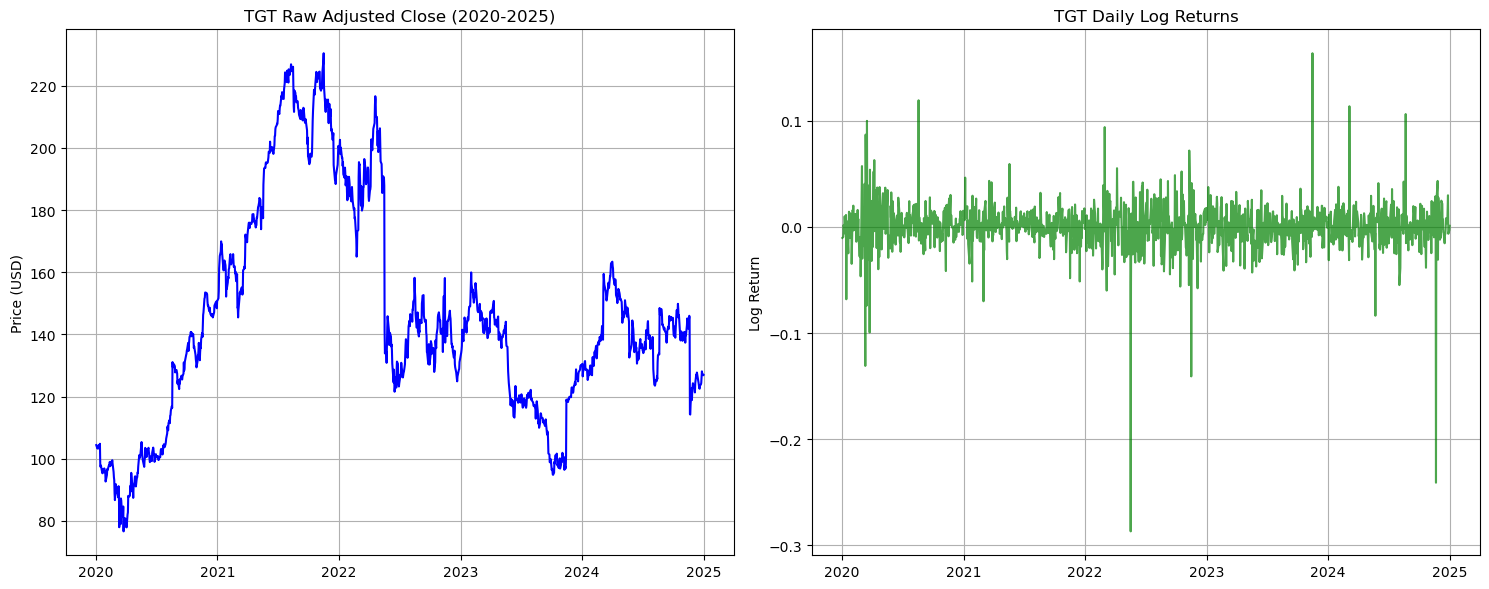

--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -36.3938
p-value: 0.0000e+00

Interpretation: The p-value (0.0000e+00) is less than 0.05.
Decision: Reject the Null Hypothesis (H0). The log return series is STATIONARY.


In [3]:
#ADF Test for Target
# 1. Install necessary libraries for visualization and statistical testing
!pip install matplotlib statsmodels numpy

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 2. Calculate daily log returns
# Formula: r_t = ln(P_t / P_{t-1})
df['log_return'] = np.log(df['Adjusted_Close'] / df['Adjusted_Close'].shift(1))

# Drop the first row which will be NaN after the shift operation
df_clean = df.dropna()

# 3. Plot Raw Prices and Log Returns side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Raw Adjusted Close Prices (Non-Stationary)
axes[0].plot(df_clean.index, df_clean['Adjusted_Close'], color='blue')
axes[0].set_title('TGT Raw Adjusted Close (2020-2025)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)

# Plot Log Returns (Stationary Candidate)
axes[1].plot(df_clean.index, df_clean['log_return'], color='green', alpha=0.7)
axes[1].set_title('TGT Daily Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 4. Perform Augmented Dickey-Fuller (ADF) Test
print("--- Augmented Dickey-Fuller Test Results ---")
result = adfuller(df_clean['log_return'])

adf_statistic = result[0]
p_value = result[1]

print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'p-value: {p_value:.4e}')

# 5. Interpret the result
if p_value < 0.05:
    print(f"\nInterpretation: The p-value ({p_value:.4e}) is less than 0.05.")
    print("Decision: Reject the Null Hypothesis (H0). The log return series is STATIONARY.")
else:
    print(f"\nInterpretation: The p-value ({p_value:.4e}) is greater than 0.05.")
    print("Decision: Fail to reject the Null Hypothesis (H0). The series is NON-STATIONARY.")

Searching for optimal ARIMA parameters...
ARIMA(p,d,q)             AIC
----------------------------
ARIMA(0,0,0)           -5907.316
ARIMA(0,0,1)           -5906.264
ARIMA(0,0,2)           -5904.327
ARIMA(0,0,3)           -5902.260
ARIMA(0,0,4)           -5901.836
ARIMA(0,0,5)           -5900.185
ARIMA(0,1,0)           -4999.342
ARIMA(0,1,1)           -5894.478
ARIMA(0,1,2)           -5893.370
ARIMA(0,1,3)           -5891.414
ARIMA(0,1,4)           -5889.427
ARIMA(0,1,5)           -5888.458
ARIMA(1,0,0)           -5906.251
ARIMA(1,0,1)           -5904.376
ARIMA(1,0,2)           -5902.420
ARIMA(1,0,3)           -5900.716
ARIMA(1,0,4)           -5901.466
ARIMA(1,0,5)           -5900.081
ARIMA(1,1,0)           -5375.354
ARIMA(1,1,1)           -5893.357
ARIMA(1,1,2)           -5890.585
ARIMA(1,1,3)           -5892.382
ARIMA(1,1,4)           -5890.181
ARIMA(1,1,5)           -5887.988
ARIMA(2,0,0)           -5904.323
ARIMA(2,0,1)           -5902.361
ARIMA(2,0,2)           -5900.326
ARIMA(2,0

D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


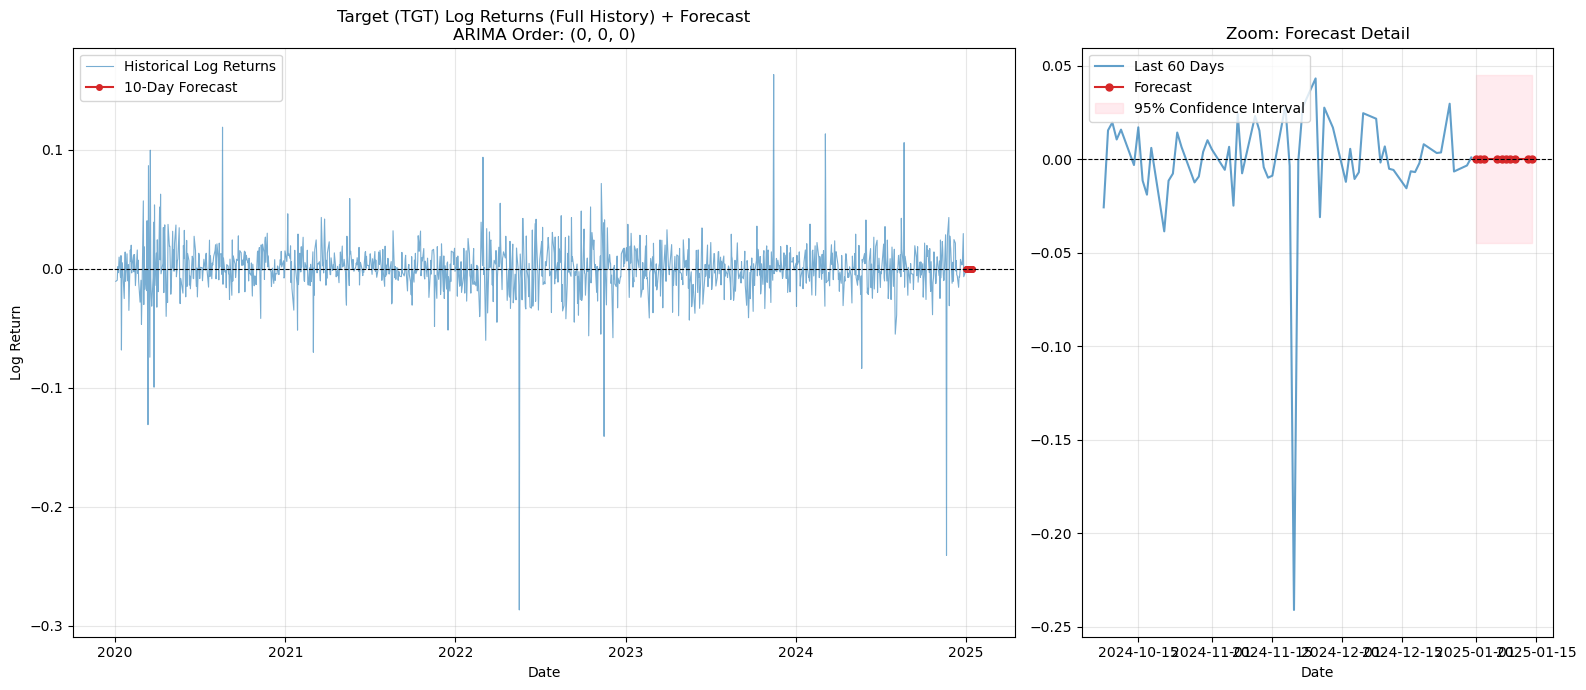

In [4]:
# ARIMA Model
# --- 1. Libraries (statsmodels only — no pmdarima/sklearn, so no import crash) ---
import numpy as np
import pandas as pd
import itertools, warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- 2. Clean return series; DO NOT mutate df (no asfreq/ffill) ---------------
# log_return already exists from the ADF cell; take a NaN-free copy for modeling.
# Leaving `df` untouched keeps the GARCH cell on the same series -> reproduces on Run-All.
ret = df['log_return'].dropna()

# --- 3. Model Selection (AIC grid search — replaces auto_arima) ---------------
print("Searching for optimal ARIMA parameters...")
print(f"{'ARIMA(p,d,q)':<16}{'AIC':>12}\n" + "-"*28)
best = {'aic': np.inf, 'order': None, 'fit': None}
for p, d, q in itertools.product(range(0, 6), range(0, 2), range(0, 6)):   # p,q≤5 ; d≤1
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = ARIMA(ret, order=(p, d, q)).fit()
        print(f"ARIMA({p},{d},{q})        {fit.aic:>12.3f}")     # trace = audit trail
        if fit.aic < best['aic']:
            best.update(aic=fit.aic, order=(p, d, q), fit=fit)
    except Exception:
        continue
best_order, results = best['order'], best['fit']
print(f"\nOptimal Model based on AIC: ARIMA{best_order}")

# --- 4. Model Fitting / summary ----------------------------------------------
print(results.summary())

# --- 5. 10-Day Forecasting ----------------------------------------------------
forecast_steps = 10
forecast_res   = results.get_forecast(steps=forecast_steps)
summary_frame  = forecast_res.summary_frame(alpha=0.05)   # call once
forecast_mean  = summary_frame['mean']
conf_int       = summary_frame
forecast_index = pd.bdate_range(ret.index[-1] + pd.tseries.offsets.BDay(1),
                                periods=forecast_steps)

# --- 6. Visualizing Results: ALL history + forecast in a different color ------
fig, (ax_full, ax_zoom) = plt.subplots(
    1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

# Left: full historical series (blue) + 10-day forecast (red)
ax_full.plot(ret.index, ret.values, label='Historical Log Returns',
             color='#1f77b4', alpha=0.6, lw=0.8)
ax_full.plot(forecast_index, forecast_mean, label='10-Day Forecast',
             color='#d62728', marker='o', markersize=4)
ax_full.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_full.set_title(f"Target (TGT) Log Returns (Full History) + Forecast\nARIMA Order: {best_order}")
ax_full.set_xlabel("Date"); ax_full.set_ylabel("Log Return")
ax_full.legend(loc='upper left'); ax_full.grid(True, alpha=0.3)

# Right: zoom (last 60d) so the flat forecast + 95% band are legible
ax_zoom.plot(ret.index[-60:], ret.tail(60), color='#1f77b4', alpha=0.7, label='Last 60 Days')
ax_zoom.plot(forecast_index, forecast_mean, color='#d62728', marker='o', markersize=5, label='Forecast')
ax_zoom.fill_between(forecast_index, conf_int['mean_ci_lower'], conf_int['mean_ci_upper'],
                     color='pink', alpha=0.3, label='95% Confidence Interval')
ax_zoom.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_zoom.set_title("Zoom: Forecast Detail"); ax_zoom.set_xlabel("Date")
ax_zoom.legend(loc='upper left'); ax_zoom.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2604.62
Distribution:      Standardized Student's t   AIC:                           5219.24
Method:                  Maximum Likelihood   BIC:                           5245.10
                                              No. Observations:                 1303
Date:                      Fri, Jun 12 2026   Df Residuals:                     1302
Time:                              18:54:54   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

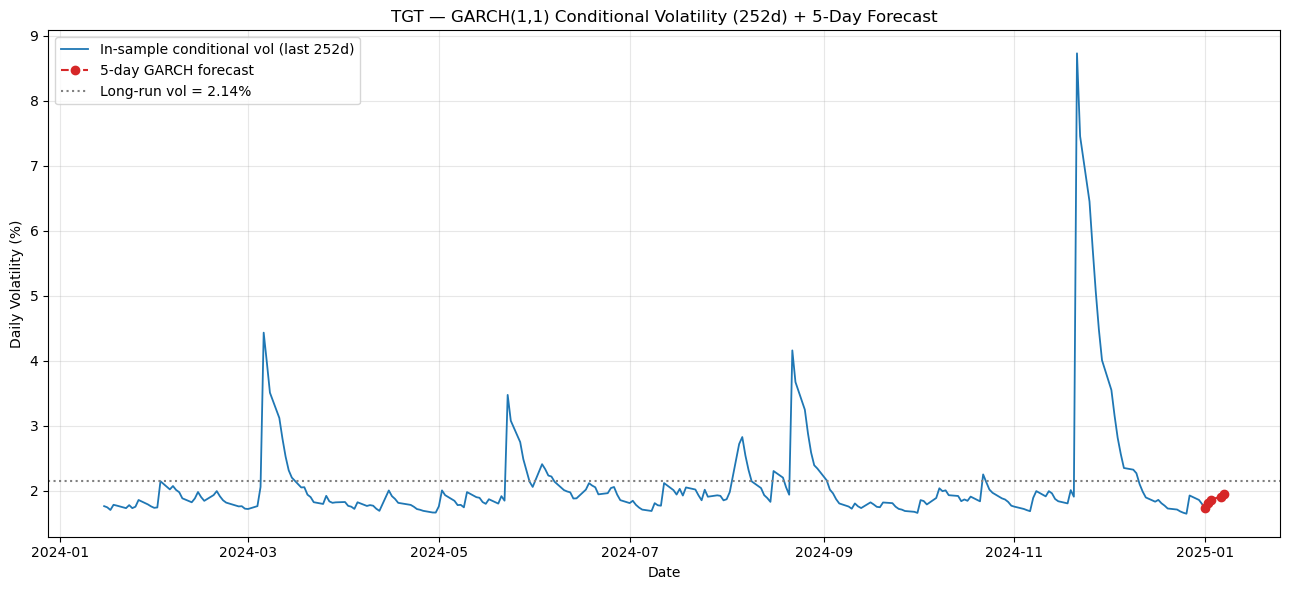

In [7]:
# ==============================================================================
#  GARCH(1,1) — 5-Day-Ahead Variance Forecast for TGT
#  Continues the pipeline. Expects `df` with a DatetimeIndex and `df['log_return']`.
# ==============================================================================

# --- 1. Libraries -------------------------------------------------------------
from arch import arch_model          # GARCH family estimation + forecasting
import numpy as np                   # numerics (sqrt, sums)
import pandas as pd                  # forecast index construction
import matplotlib.pyplot as plt      # visualization

# --- 2. Prepare the return series --------------------------------------------
# Scale log returns by 100 (→ % returns). GARCH MLE optimizers are numerically
# unstable on raw ~1e-2 decimals; %-scale keeps the gradients well-conditioned.
returns = (100 * df['log_return']).dropna()

# --- 3. Specify & fit GARCH(1,1) ---------------------------------------------
# dist='t' (Student-t), NOT Normal: TGT log returns are heavily fat-tailed
# (excess kurtosis ≈ 38 from the ADF/ARIMA stage). A Normal forces alpha to
# over-react to crash days (COVID-2020, the May-2022 −25% earnings gap); the
# t-distribution absorbs those tails so the persistence term stays meaningful.
# (Set dist='Normal' to revert to the original spec.)
model = arch_model(returns, mean='Constant', vol='Garch', p=1, q=1, dist='t')
res   = model.fit(disp='off')        # disp='off' suppresses optimizer iteration logs
print(res.summary())

# --- 3a. Structural diagnostics (the numbers that actually matter) -----------
omega = res.params['omega']                      # baseline variance
alpha = res.params['alpha[1]']                   # reaction to yesterday's shock
beta  = res.params['beta[1]']                    # memory of yesterday's variance
persistence = alpha + beta                       # ← TRUE persistence is α+β, not β
lr_vol      = np.sqrt(omega / (1 - persistence)) # unconditional (long-run) daily vol
half_life   = np.log(0.5) / np.log(persistence)  # days for a vol shock to half-decay

print(f"\nPersistence (alpha+beta) : {persistence:.4f}")
print(f"Long-run daily vol       : {lr_vol:.4f}%")
print(f"Vol-shock half-life      : {half_life:.2f} days")

# --- 4. 5-day-ahead variance forecast ----------------------------------------
H  = 5
fc = res.forecast(horizon=H, reindex=False)      # analytic multi-step forecast
var_5d = fc.variance.values[-1, :]               # daily conditional variance, h=1..5 (%²)
vol_5d = np.sqrt(var_5d)                          # daily conditional volatility (%)
cum_vol_5d = np.sqrt(var_5d.sum())               # total volatility over the 5-day window
ann_vol_5d = vol_5d * np.sqrt(252)               # annualized vol per forecast day (252 td/yr)

# Future business-day stamps for a clean, gap-free forecast axis
fc_index = pd.bdate_range(df.index[-1] + pd.tseries.offsets.BDay(1), periods=H)

forecast_table = pd.DataFrame({
    'Daily Variance (%²)': var_5d,
    'Daily Vol (%)'      : vol_5d,
    'Annualized Vol (%)' : ann_vol_5d,
}, index=[f'T+{i}' for i in range(1, H + 1)])

print("\n--- 5-Day-Ahead Forecast ---")
print(forecast_table.round(4))
print(f"\nCumulative 5-day volatility: {cum_vol_5d:.4f}%")

# --- 5. Plot: trailing 252d conditional vol + 5-day forecast -----------------
cond_vol = res.conditional_volatility            # in-sample fitted daily vol (%)
hist     = cond_vol.iloc[-252:]                  # last trading year for context

plt.figure(figsize=(13, 6))
plt.plot(hist.index, hist.values, color='#1f77b4', lw=1.3,
         label='In-sample conditional vol (last 252d)')
plt.plot(fc_index, vol_5d, color='#d62728', marker='o', ls='--',
         label='5-day GARCH forecast')
# bridge the last fitted point to the first forecast point so the line is continuous
plt.plot([hist.index[-1], fc_index[0]], [hist.values[-1], vol_5d[0]],
         color='#d62728', ls='--', alpha=0.6)
plt.axhline(lr_vol, color='gray', ls=':', label=f'Long-run vol = {lr_vol:.2f}%')
plt.title('TGT — GARCH(1,1) Conditional Volatility (252d) + 5-Day Forecast')
plt.xlabel('Date'); plt.ylabel('Daily Volatility (%)')
plt.legend(loc='upper left'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()